<a href="https://colab.research.google.com/github/anissa80/prediksi-harga-mobil-bekas/blob/main/Anissa_Salsabila_E1E124029_Teknik_Informatika_Kelas_A_Pembelajaran_Mesin(Regresi).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Prediksi Harga Mobil Bekas Berdasarkan Spesifikasi Mesin dan Jarak Tempuh Menggunakan Algoritma Linear Regression, Decision Tree dan Random Forest Regressor**

**1. Import Library & Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
from sklearn.metrics import r2_score

# Mengabaikan warnings agar output rapi
warnings.filterwarnings('ignore')

print("=== TAHAP 1: DATA UNDERSTANDING ===")
df = pd.read_csv('used_cars.csv')

print("1. Tampilan Data Awal:")
display(df.head())

print("\n2. Informasi Dataset:")
df.info()

print("\n3. Statistik Deskriptif (Numerik):")
display(df.describe())

print("\n4. Statistik Deskriptif (Kategorikal):")
display(df.describe(include=['object']))

print("\n5. 10 Data Pertama Dataset :")
display(df.iloc[:10])

=== TAHAP 1: DATA UNDERSTANDING ===
1. Tampilan Data Awal:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"



2. Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB

3. Statistik Deskriptif (Numerik):


,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000



4. Statistik Deskriptif (Kategorikal):


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39



5. 10 Data Pertama Dataset :


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


**2. Data Preprocessing**

In [2]:
print("=== TAHAP 2: DATA PREPROCESSING ===")

# 1. Mengatasi Missing Values & Tipe Data
df['clean_title'] = df['clean_title'].fillna('No')
df['accident'] = df['accident'].fillna('None reported')
df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df = df.dropna()

df['milage'] = df['milage'].astype(str).str.replace(' mi', '').str.replace(',', '').astype(float)
df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# 2. Filter Data Murni & Outlier (Metode IQR)
df = df[(df['accident'] == 'None reported') & (df['clean_title'] == 'Yes')]
df = df[df['model_year'] >= 2015]

def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df = remove_outliers(df, 'price')
df = remove_outliers(df, 'milage')

# 3. Feature Engineering
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

df['engine_vol_L'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
df['engine_vol_Liter'] = df['engine'].str.extract(r'(\d+\.?\d*) Liter').astype(float)
df['engine_volume'] = df['engine_vol_L'].fillna(df['engine_vol_Liter'])
df['engine_volume'] = df['engine_volume'].fillna(df['engine_volume'].median())

current_year = datetime.now().year
df['car_age'] = current_year - df['model_year']
df['car_age'] = df['car_age'].replace(0, 1)
df['milage_per_year'] = df['milage'] / df['car_age']
df['brand_model'] = df['brand'] + '_' + df['model']

# 4. Encoding
bm_mean = df.groupby('brand_model')['price'].mean()
df['brand_model_encoded'] = df['brand_model'].map(bm_mean)

le_trans = LabelEncoder()
df['transmission_encoded'] = le_trans.fit_transform(df['transmission'])

le_fuel = LabelEncoder()
df['fuel_encoded'] = le_fuel.fit_transform(df['fuel_type'])

features = [
    'brand_model_encoded', 'car_age', 'milage', 'milage_per_year',
    'horsepower', 'engine_volume', 'transmission_encoded', 'fuel_encoded', 'price'
]

df_final = df[features].dropna()
print(f"[SUKSES] Data prapemrosesan selesai! Tersisa {len(df_final)} baris data siap latih.")

=== TAHAP 2: DATA PREPROCESSING ===
[SUKSES] Data prapemrosesan selesai! Tersisa 1474 baris data siap latih.


**3. Exploratory Data Analysis (EDA)**

=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ===


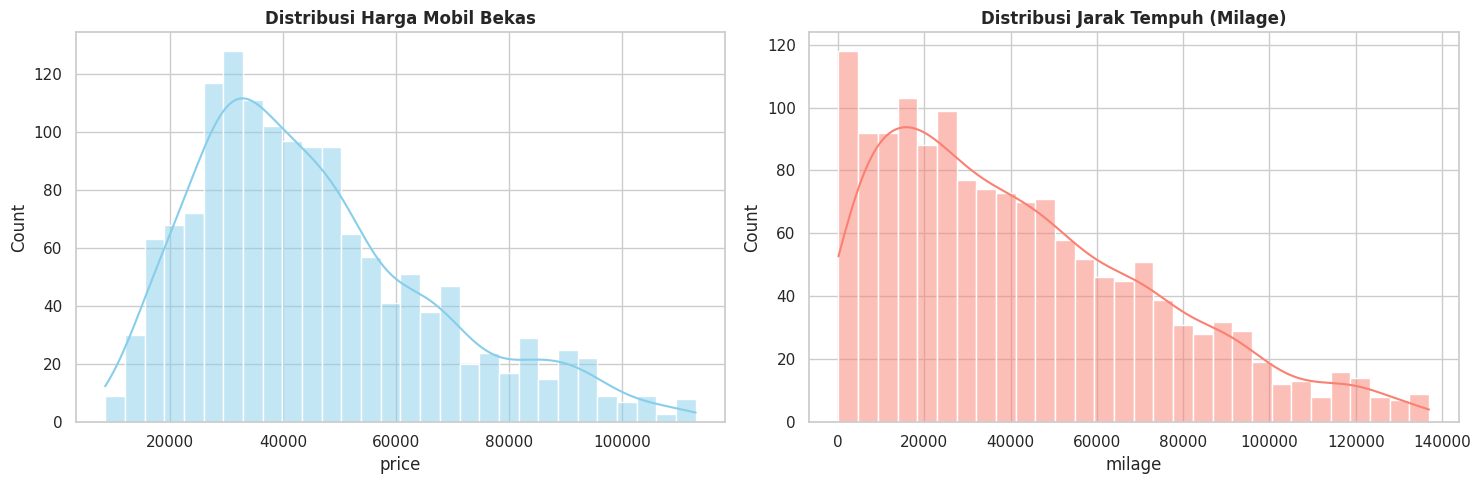

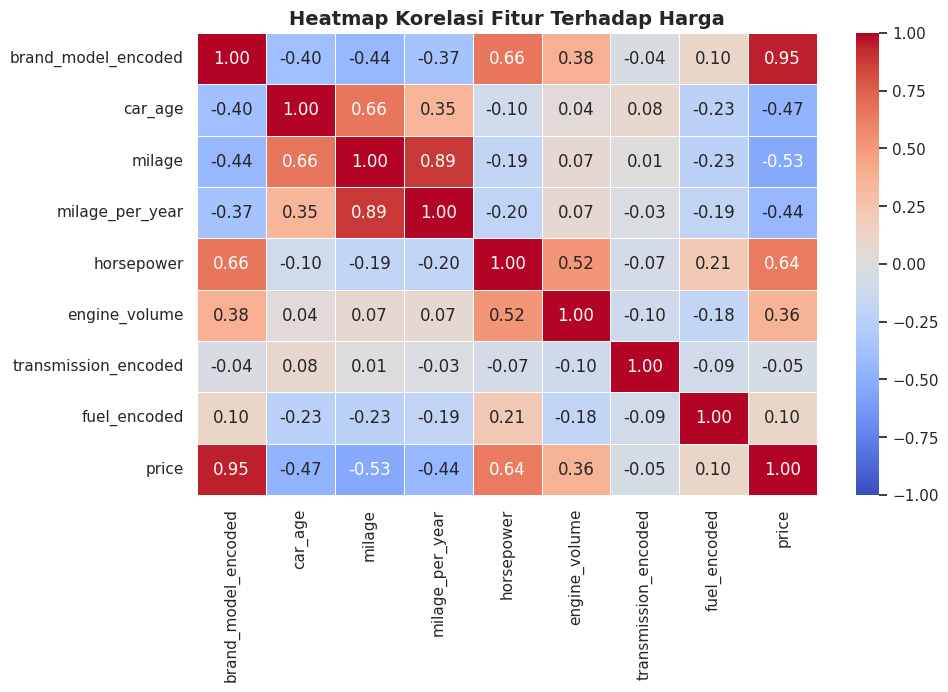

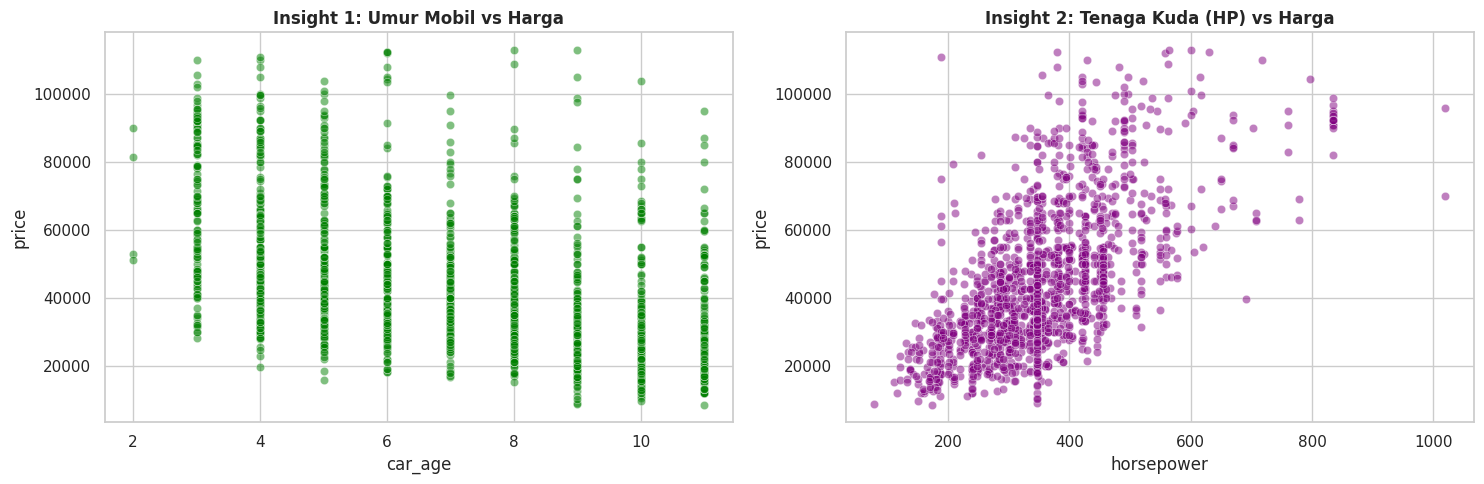

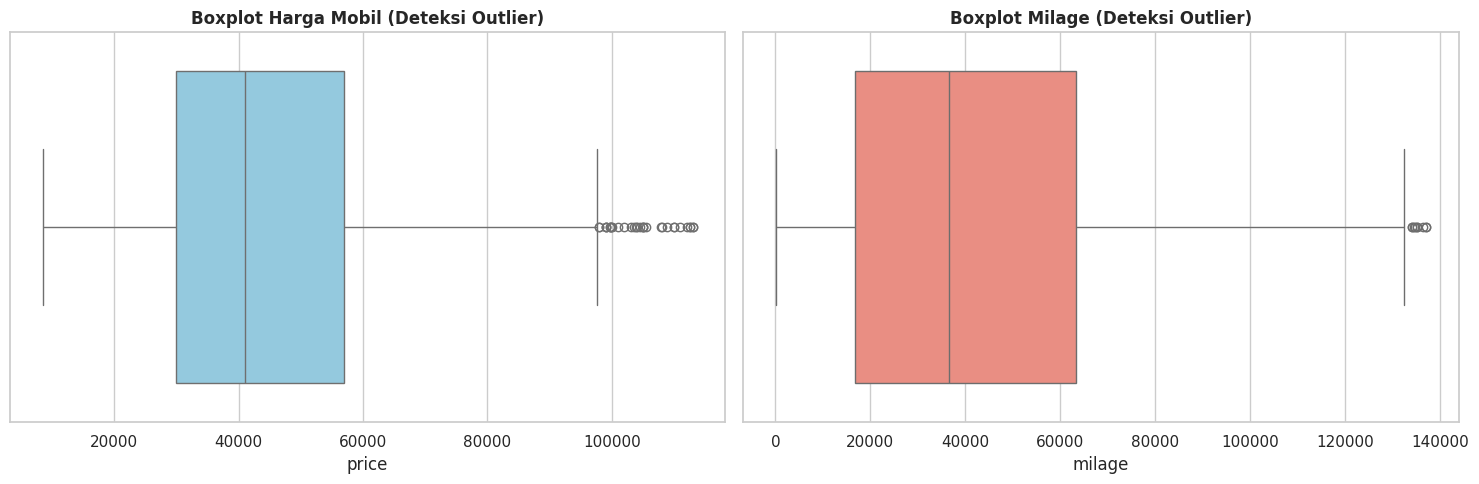

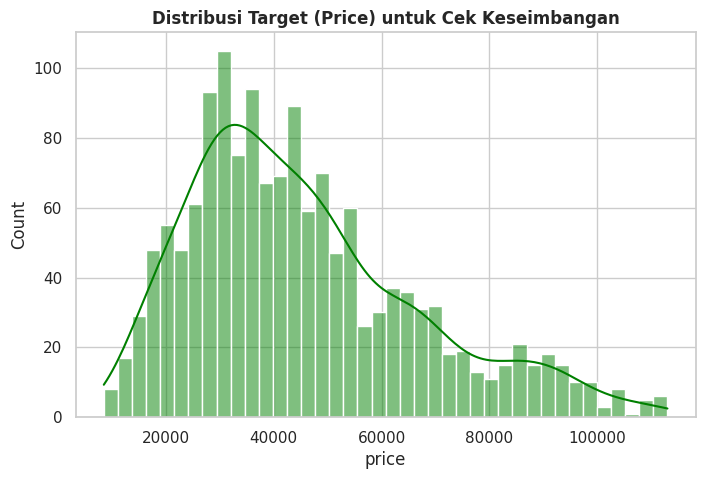

📊 SKEWNESS HARGA: 0.853
-> Nilai positif menunjukkan distribusi condong ke kanan (right-skewed).
-> Artinya: Mayoritas mobil berada di rentang harga menengah ke bawah, dan hanya sedikit mobil di harga sangat tinggi.

🔗 KORELASI FITUR TERHADAP HARGA (Tertinggi ke Terendah):


,price
brand_model_encoded,0.951921
horsepower,0.636422
engine_volume,0.361096
fuel_encoded,0.103060
transmission_encoded,-0.047264
milage_per_year,-0.438870
car_age,-0.473987
milage,-0.532884


In [3]:
print("=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) ===")
sns.set_theme(style="whitegrid")

# 1. Distribusi Data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_final['price'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Harga Mobil Bekas', fontweight='bold')
sns.histplot(df_final['milage'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribusi Jarak Tempuh (Milage)', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Heatmap Korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Terhadap Harga', fontsize=14, fontweight='bold')
plt.show()

# 3. Insight Penting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x='car_age', y='price', data=df_final, alpha=0.5, color='green', ax=axes[0])
axes[0].set_title('Insight 1: Umur Mobil vs Harga', fontweight='bold')
sns.scatterplot(x='horsepower', y='price', data=df_final, alpha=0.5, color='purple', ax=axes[1])
axes[1].set_title('Insight 2: Tenaga Kuda (HP) vs Harga', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df_final['price'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Harga Mobil (Deteksi Outlier)', fontweight='bold')
sns.boxplot(x=df_final['milage'], color='salmon', ax=axes[1])
axes[1].set_title('Boxplot Milage (Deteksi Outlier)', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Distribusi Target
plt.figure(figsize=(8,5))
sns.histplot(df_final['price'], bins=40, kde=True, color='green')
plt.title("Distribusi Target (Price) untuk Cek Keseimbangan", fontweight='bold')
plt.show()

# 6. Skewness Target
skew_val = df_final['price'].skew()
print(f"📊 SKEWNESS HARGA: {skew_val:.3f}")
print("-> Nilai positif menunjukkan distribusi condong ke kanan (right-skewed).")
print("-> Artinya: Mayoritas mobil berada di rentang harga menengah ke bawah, dan hanya sedikit mobil di harga sangat tinggi.\n")

# 7. Korelasi Target
print("🔗 KORELASI FITUR TERHADAP HARGA (Tertinggi ke Terendah):")
korelasi_harga = df_final.corr()[['price']].sort_values(by='price', ascending=False)

display(korelasi_harga.drop('price').style.background_gradient(cmap='coolwarm'))

**4. Data Splitting & Feature Scaling**

In [4]:
print("=== TAHAP 4: DATA SPLITTING & FEATURE SCALING ===")

X = df_final.drop('price', axis=1)
y = df_final['price']

splits = [(0.3, "70:30"), (0.2, "80:20"), (0.1, "90:10")]
split_data = {}
scalers = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    split_data[label] = (X_train_scaled, X_test_scaled, y_train, y_test)
    scalers[label] = scaler
    print(f"✅ Skenario Split {label} Berhasil! (Train: {X_train_scaled.shape[0]} baris, Test: {X_test_scaled.shape[0]} baris)")

print("\n--- BUKTI STANDARD SCALER ---")
print("Contoh hasil scaling (5 baris pertama dari skenario terakhir):")
print(X_train_scaled[:5])
print("Standard Scaler menstandarisasi data sehingga setiap fitur memiliki mean ≈ 0 dan standar deviasi ≈ 1 agar model machine learning tidak bias terhadap skala fitur.")

=== TAHAP 4: DATA SPLITTING & FEATURE SCALING ===
✅ Skenario Split 70:30 Berhasil! (Train: 1031 baris, Test: 443 baris)
✅ Skenario Split 80:20 Berhasil! (Train: 1179 baris, Test: 295 baris)
✅ Skenario Split 90:10 Berhasil! (Train: 1326 baris, Test: 148 baris)

--- BUKTI STANDARD SCALER ---
Contoh hasil scaling (5 baris pertama dari skenario terakhir):
[[-0.76019668 -1.56783335 -1.16943795 -1.08573691 -1.07687173 -0.85558654
  -0.73110594 -0.28764519]
 [-0.64133226 -0.3499382  -0.0469229   0.30560749 -0.63949309 -1.14590904
   0.0110067  -0.28764519]
 [-1.62282682  1.27392201  2.4404684   1.74427652 -0.63108196  0.01538096
   0.62943389 -0.28764519]
 [ 1.37591033 -1.56783335 -1.26112064 -1.35785359 -0.08435866 -1.14590904
  -0.23636418 -0.28764519]
 [-1.22825615  0.4619919  -0.45086887 -0.62906597 -1.44696135 -0.78300592
   1.37154653 -0.28764519]]
Standard Scaler menstandarisasi data sehingga setiap fitur memiliki mean ≈ 0 dan standar deviasi ≈ 1 agar model machine learning tidak bias 

**5. Model Building & Hyperparameter Tuning**

In [5]:
print("=== TAHAP 5: MODEL BUILDING & HYPERPARAMETER TUNING ===")

param_grids = {
    'Linear Regression': {'fit_intercept': [True, False]},
    'Decision Tree': {'max_depth': [10, 15, 20], 'min_samples_split': [2, 4, 6], 'min_samples_leaf': [1, 2]},
    'Random Forest': {'n_estimators': [100, 300, 500], 'max_depth': [None, 15, 20, 25], 'min_samples_split': [2, 4]}
}

experiment_results = []
print("Mulai melatih algoritma pada 3 skenario pembagian data...\n")

for label, (X_tr, X_ts, y_tr, y_ts) in split_data.items():
    print(f">> Pelatihan untuk Skenario Split {label}:")

    for name, params in param_grids.items():
        if name == 'Linear Regression': base_model = LinearRegression()
        elif name == 'Decision Tree': base_model = DecisionTreeRegressor(random_state=42)
        else: base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

        tuning = RandomizedSearchCV(estimator=base_model, param_distributions=params,
                                    n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1)
        tuning.fit(X_tr, y_tr)
        best_model = tuning.best_estimator_
        y_pred = best_model.predict(X_ts)

        experiment_results.append({
            'Skenario': label, 'Algoritma': name, 'Best Params': tuning.best_params_,
            'Model Terbaik': best_model, 'y_test': y_ts, 'y_pred': y_pred
        })
        print(f"   [Selesai] {name}")
print("\n[SUKSES] Seluruh model berhasil dibangun dan di tuning!")

=== TAHAP 5: MODEL BUILDING & HYPERPARAMETER TUNING ===
Mulai melatih algoritma pada 3 skenario pembagian data...

>> Pelatihan untuk Skenario Split 70:30:
   [Selesai] Linear Regression
   [Selesai] Decision Tree
   [Selesai] Random Forest
>> Pelatihan untuk Skenario Split 80:20:
   [Selesai] Linear Regression
   [Selesai] Decision Tree
   [Selesai] Random Forest
>> Pelatihan untuk Skenario Split 90:10:
   [Selesai] Linear Regression
   [Selesai] Decision Tree
   [Selesai] Random Forest

[SUKSES] Seluruh model berhasil dibangun dan di tuning!


**6. Hasil Hyperparameter Tuning**

In [6]:
print("=== TAHAP 6: HASIL HYPERPARAMETER TUNING ===")
tuning_summary = []

for res in experiment_results:
    tuning_summary.append({
        'Skenario Split': res['Skenario'],
        'Algoritma': res['Algoritma'],
        'Parameter Terbaik': str(res['Best Params'])
    })

df_tuning = pd.DataFrame(tuning_summary)
display(df_tuning)

=== TAHAP 6: HASIL HYPERPARAMETER TUNING ===


,Skenario Split,Algoritma,Parameter Terbaik
0,70:30,Linear Regression,{'fit_intercept': True}
1,70:30,Decision Tree,"{'min_samples_split': 6, 'min_samples_leaf': 2..."
2,70:30,Random Forest,"{'n_estimators': 500, 'min_samples_split': 4, ..."
3,80:20,Linear Regression,{'fit_intercept': True}
4,80:20,Decision Tree,"{'min_samples_split': 6, 'min_samples_leaf': 2..."
5,80:20,Random Forest,"{'n_estimators': 500, 'min_samples_split': 4, ..."
6,90:10,Linear Regression,{'fit_intercept': True}
7,90:10,Decision Tree,"{'min_samples_split': 6, 'min_samples_leaf': 2..."
8,90:10,Random Forest,"{'n_estimators': 300, 'min_samples_split': 4, ..."


**7. Model Evaluation**

=== TAHAP 7: MODEL EVALUATION ===

--- TABEL PERBANDINGAN PERFORMA MODEL ---


,Skenario Split,Algoritma,R2 Score,MAE,MSE,RMSE
6,90:10,Linear Regression,0.936944,3934.256425,3.236620e+07,5689.129977
3,80:20,Linear Regression,0.930548,4094.902900,3.435178e+07,5861.039505
0,70:30,Linear Regression,0.930016,4077.878610,3.265224e+07,5714.213811
5,80:20,Random Forest,0.922249,4207.893586,3.845669e+07,6201.346141
8,90:10,Random Forest,0.921205,4279.613988,4.044511e+07,6359.647319
7,90:10,Decision Tree,0.917084,4479.395677,4.256022e+07,6523.819632
2,70:30,Random Forest,0.914999,4176.685822,3.965862e+07,6297.508959
1,70:30,Decision Tree,0.880554,4907.200212,5.572975e+07,7465.235922
4,80:20,Decision Tree,0.876039,5111.322037,6.131286e+07,7830.253087


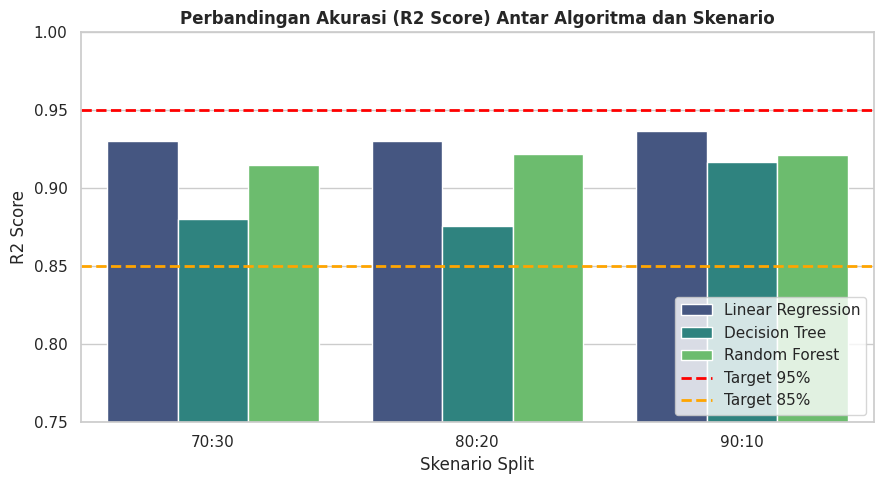

In [7]:
print("=== TAHAP 7: MODEL EVALUATION ===")
evaluation_list = []

for res in experiment_results:
    y_test = res['y_test']
    y_pred = res['y_pred']

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    evaluation_list.append({
        'Skenario Split': res['Skenario'], 'Algoritma': res['Algoritma'],
        'R2 Score': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse
    })

df_eval = pd.DataFrame(evaluation_list)
print("\n--- TABEL PERBANDINGAN PERFORMA MODEL ---")
display(df_eval.sort_values(by='R2 Score', ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=df_eval, x='Skenario Split', y='R2 Score', hue='Algoritma', palette='viridis')
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='Target 95%')
plt.axhline(y=0.85, color='orange', linestyle='--', linewidth=2, label='Target 85%')
plt.title('Perbandingan Akurasi (R2 Score) Antar Algoritma dan Skenario', fontweight='bold')
plt.ylim(0.75, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**8. Model Comparison & Kesimpulan**

=== TAHAP 8: MODEL COMPARISON ===

[A] TABEL PIVOT R2 SCORE BERDASARKAN SPLITTING


Skenario Split,70:30,80:20,90:10,Rata-rata Akurasi
Algoritma,,,,
Linear Regression,0.930016,0.930548,0.936944,0.932503
Random Forest,0.914999,0.922249,0.921205,0.919484
Decision Tree,0.880554,0.876039,0.917084,0.891225



[B] TABEL RATA-RATA ERROR (MAE & RMSE)


,MAE,RMSE
Algoritma,,
Linear Regression,4035.679312,5754.794431
Random Forest,4221.397799,6286.167473
Decision Tree,4832.639308,7273.102880


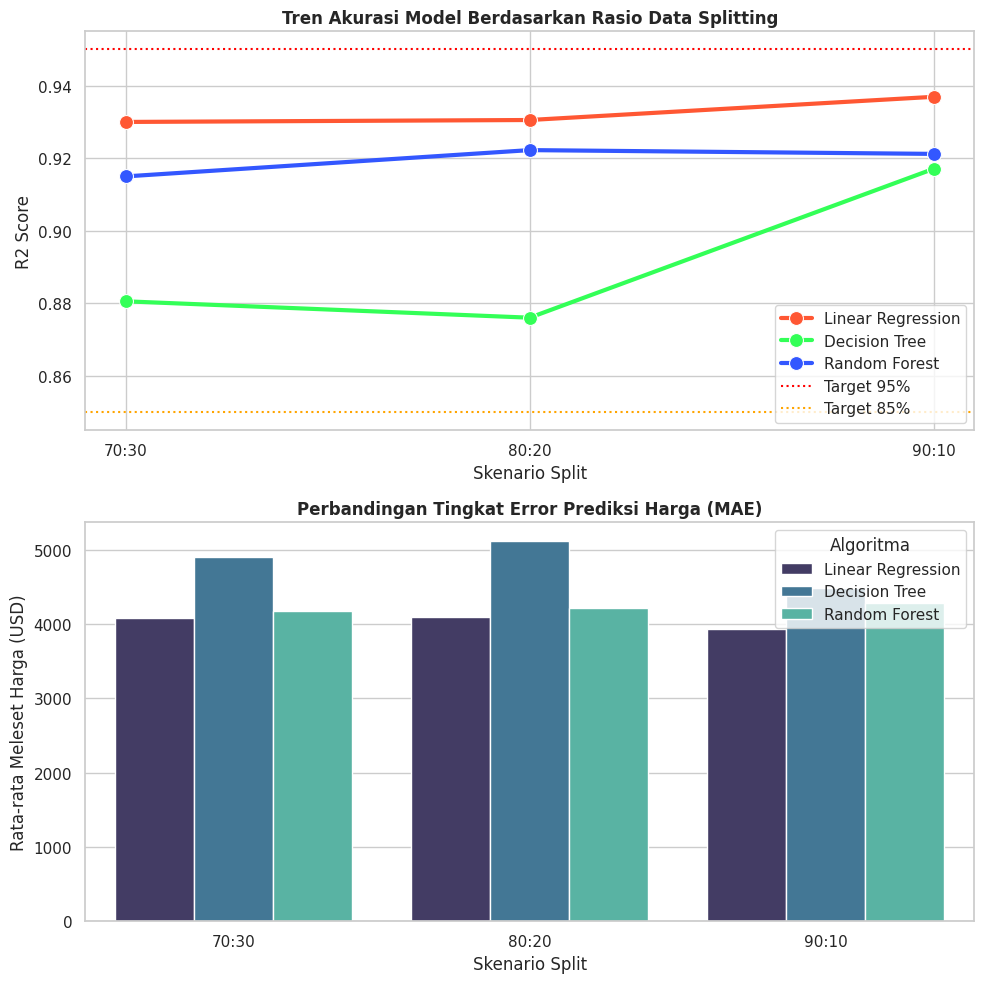

In [8]:
print("=== TAHAP 8: MODEL COMPARISON ===")

# 1. Pivot Table Akurasi
print("\n[A] TABEL PIVOT R2 SCORE BERDASARKAN SPLITTING")
pivot_r2 = df_eval.pivot(index='Algoritma', columns='Skenario Split', values='R2 Score')
pivot_r2['Rata-rata Akurasi'] = pivot_r2.mean(axis=1)
display(pivot_r2.sort_values(by='Rata-rata Akurasi', ascending=False))

# 2. Tabel Rata-rata Error
print("\n[B] TABEL RATA-RATA ERROR (MAE & RMSE)")
avg_error = df_eval.groupby('Algoritma')[['MAE', 'RMSE']].mean().sort_values(by='MAE')
display(avg_error)

# 3. Visualisasi Tren dan Error
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
sns.lineplot(data=df_eval, x='Skenario Split', y='R2 Score', hue='Algoritma',
             marker='o', markersize=10, linewidth=3, palette=['#FF5733', '#33FF57', '#3357FF'], ax=axes[0])
axes[0].set_title('Tren Akurasi Model Berdasarkan Rasio Data Splitting', fontweight='bold')
axes[0].axhline(y=0.95, color='red', linestyle=':', label='Target 95%')
axes[0].axhline(y=0.85, color='orange', linestyle=':', label='Target 85%')
axes[0].legend()

sns.barplot(data=df_eval, x='Skenario Split', y='MAE', hue='Algoritma', palette='mako', ax=axes[1])
axes[1].set_title('Perbandingan Tingkat Error Prediksi Harga (MAE)', fontweight='bold')
axes[1].set_ylabel('Rata-rata Meleset Harga (USD)')
plt.tight_layout()
plt.show()

**9. Eksekusi Model Saving & Simulasi**

=== TAHAP 9: EVALUASI AKHIR, MODEL SAVING & DEPLOYMENT SIMULATION ===

[1] Model Terbaik Ditemukan: Linear Regression (Skenario 90:10) dengan Akurasi 93.69%
Train Score : 0.9253
Test Score  : 0.9369
Indikasi: Model seimbang (Good Fit).


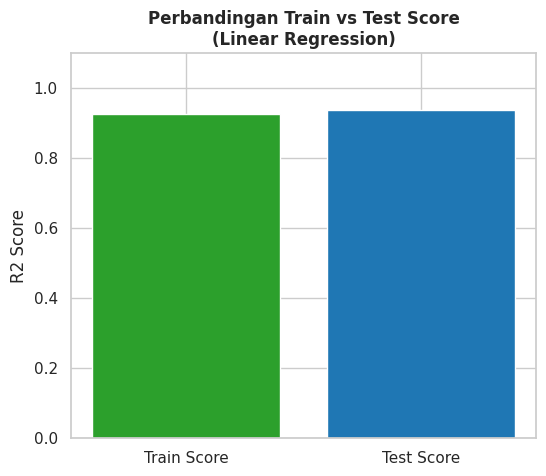

[2] Model berhasil disimpan sebagai: 'used_car_best_model.pkl'
    Daftar fitur disimpan sebagai: 'model_features.pkl'

--- SIMULASI APLIKASI PREDIKSI HARGA MOBIL ---
Misalkan seorang pengguna memasukkan spesifikasi mobil di Website:

 > Brand: Ford
 > Model: Mustang
 > Model_year: 2019
 > Milage: 35000
 > Engine: 300.0HP 2.3L I4 Cylinder Engine
 > Transmission: Automatic
 > Fuel_type: Gasoline
💰 ESTIMASI HARGA JUAL MOBIL: $38,971.23


In [9]:
print("=== TAHAP 9: EVALUASI AKHIR, MODEL SAVING & DEPLOYMENT SIMULATION ===\n")

# 1. MENCARI MODEL TERBAIK DARI SELURUH EKSPERIMEN
best_score = -1
best_model = None
best_split_name = ""
best_algo = ""

for res in experiment_results:
    r2 = r2_score(res['y_test'], res['y_pred'])
    if r2 > best_score:
        best_score = r2
        best_model = res['Model Terbaik']
        best_split_name = res['Skenario']
        best_algo = res['Algoritma']

print(f"[1] Model Terbaik Ditemukan: {best_algo} (Skenario {best_split_name}) dengan Akurasi {best_score*100:.2f}%")

best_scaler = scalers[best_split_name]

# 2. OVERFITTING & FEATURE IMPORTANCE
# Mengambil data dari skenario terbaik
X_tr_best, X_ts_best, y_tr_best, y_ts_best = split_data[best_split_name]

train_score = best_model.score(X_tr_best, y_tr_best)
test_score = best_model.score(X_ts_best, y_ts_best)

print(f"Train Score : {train_score:.4f}")
print(f"Test Score  : {test_score:.4f}")

if train_score > test_score + 0.05:
    print("Indikasi: Model mengalami Overfitting (Terlalu menghafal data latih).")
elif train_score < 0.75 and test_score < 0.75:
    print("Indikasi: Model mengalami Underfitting (Gagal menangkap pola data).")
else:
    print("Indikasi: Model seimbang (Good Fit).")

# Grafik Perbandingan
plt.figure(figsize=(6,5))
plt.bar(['Train Score', 'Test Score'], [train_score, test_score], color=['#2ca02c', '#1f77b4'])
plt.title(f"Perbandingan Train vs Test Score\n({best_algo})", fontweight='bold')
plt.ylabel("R2 Score")
plt.ylim(0, 1.1)
plt.show()

# Grafik Feature Importance
if best_algo in ['Decision Tree', 'Random Forest']:
    importance = best_model.feature_importances_
    feat_imp = pd.Series(importance, index=X.columns)

    plt.figure(figsize=(8,5))
    feat_imp.sort_values().plot(kind='barh', color='purple')
    plt.title("Feature Importance (Tingkat Kepentingan Fitur)", fontweight='bold')
    plt.xlabel("Bobot")
    plt.show()

# 3. MENYIMPAN MODEL
model_filename = 'used_car_best_model.pkl'
features_filename = 'model_features.pkl'

joblib.dump(best_model, model_filename)
joblib.dump(features, features_filename)

print(f"[2] Model berhasil disimpan sebagai: '{model_filename}'")
print(f"    Daftar fitur disimpan sebagai: '{features_filename}'\n")

# 4. SIMULASI DEPLOYMENT
print("--- SIMULASI APLIKASI PREDIKSI HARGA MOBIL ---")
print("Misalkan seorang pengguna memasukkan spesifikasi mobil di Website:\n")

# Contoh input data baru
data_baru = {
    'brand': 'Ford',
    'model': 'Mustang',
    'model_year': 2019,
    'milage': 35000,
    'engine': '300.0HP 2.3L I4 Cylinder Engine',
    'transmission': 'Automatic',
    'fuel_type': 'Gasoline'
}

for key, value in data_baru.items():
    print(f" > {key.capitalize()}: {value}")

# Proses Preprocessing data baru
current_year = datetime.now().year
car_age_baru = current_year - data_baru['model_year']
car_age_baru = 1 if car_age_baru == 0 else car_age_baru
milage_per_year_baru = data_baru['milage'] / car_age_baru
brand_model_baru = data_baru['brand'] + '_' + data_baru['model']

bm_encoded_baru = bm_mean.get(brand_model_baru, bm_mean.median())
trans_encoded_baru = le_trans.transform([data_baru['transmission']])[0] if data_baru['transmission'] in le_trans.classes_ else 0
fuel_encoded_baru = le_fuel.transform([data_baru['fuel_type']])[0] if data_baru['fuel_type'] in le_fuel.classes_ else 0

# Ekstraksi Mesin
import re
hp_match = re.search(r'(\d+\.?\d*)HP', data_baru['engine'])
hp_baru = float(hp_match.group(1)) if hp_match else df_final['horsepower'].median()

vol_match = re.search(r'(\d+\.?\d*)L', data_baru['engine'])
vol_baru = float(vol_match.group(1)) if vol_match else df_final['engine_volume'].median()

# Menyusun input final
input_df = pd.DataFrame([[
    bm_encoded_baru, car_age_baru, data_baru['milage'], milage_per_year_baru,
    hp_baru, vol_baru, trans_encoded_baru, fuel_encoded_baru
]], columns=features[:-1])

# Scaling khusus untuk input baru
input_scaled = best_scaler.transform(input_df)

# Melakukan Prediksi
harga_prediksi = best_model.predict(input_scaled)[0]

print("===================================================")
print(f"💰 ESTIMASI HARGA JUAL MOBIL: ${harga_prediksi:,.2f}")
print("===================================================")

**10. Simpan Scaler**

In [10]:
print("=== TAHAP 10: SIMPAN SCALER & ENCODER ===\n")
# Menyimpan model components
joblib.dump(best_scaler, 'scaler.pkl')
joblib.dump(le_trans, 'le_trans.pkl')
joblib.dump(le_fuel, 'le_fuel.pkl')
joblib.dump(bm_mean.to_dict(), 'bm_mean_dict.pkl')
print("✅ Scaler, Encoders (Trans & Fuel), dan Brand Mapping berhasil disimpan!")

=== TAHAP 10: SIMPAN SCALER & ENCODER ===

✅ Scaler, Encoders (Trans & Fuel), dan Brand Mapping berhasil disimpan!
